<a href="https://colab.research.google.com/github/gabrielhierro/LinguagensDeProgramacao/blob/main/ExercicioPratico1/Projeto_1_Dengue_Sudeste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Projeto 1 — Evolução dos Casos de Dengue nos Estados do Sudeste (2015–2024)

**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python  
**Objetivo do projeto:** Analisar a evolução dos casos de dengue nos estados do Sudeste, identificando picos, tendências e diferenças entre estados, com base nas orientações das aulas 1 a 6.

---
## Estrutura do notebook
1. Título e introdução  
2. Definição do problema  
3. Definição do KPI  
4. Aquisição dos dados  
5. Limpeza e preparação dos dados  
6. Análise exploratória  
7. Visualizações  
8. Insights e interpretação  
9. Conclusão  
10. Reflexão final (data storytelling)



## 1. Introdução

A dengue é uma doença viral transmitida pelo mosquito *Aedes aegypti* e representa um importante problema de saúde pública no Brasil. A análise temporal dos casos permite identificar padrões de crescimento, anos críticos e diferenças regionais, apoiando decisões de prevenção, monitoramento e alocação de recursos.

Neste projeto, vamos investigar a evolução dos casos confirmados de dengue nos estados da região Sudeste entre 2015 e 2024.



## 2. Definição do problema

**Pergunta de análise:**  
Como os casos confirmados de dengue evoluíram nos estados do Sudeste entre 2015 e 2024, e quais estados apresentaram os maiores volumes e os anos mais críticos?

**Por que essa pergunta é relevante?**  
Porque ajuda a identificar estados e períodos de maior risco, apoiando ações de vigilância epidemiológica, campanhas educativas e políticas públicas de combate ao mosquito.

**Qual decisão poderia ser tomada com base nessa análise?**  
Direcionar campanhas de prevenção, ampliar ações de controle vetorial e priorizar estados/anos mais críticos para intervenção.



## 3. Definição do KPI

### KPI principal
**Total de casos confirmados de dengue por estado e por ano**

### Justificativa
Esse indicador permite comparar:
- a evolução temporal da doença;
- os estados mais afetados;
- os anos com maior incidência.

### Fórmula
\[
	ext{Total de Casos Confirmados} = \sum 	ext{Casos Confirmados}
\]

### KPI complementar
**Variação percentual anual dos casos por estado**

Esse indicador ajuda a identificar anos de crescimento ou queda mais acentuados.


In [1]:

# 4. Aquisição dos dados
# Importação das bibliotecas principais trabalhadas nas aulas 1 a 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

# Leitura da base de dados
df = pd.read_excel("Simulacao_Dengue_Sudeste_2015_2024.xlsx")

# Visualização inicial
df.head()


,Ano,Estado,Casos Confirmados
0,2015,SP,20795
1,2016,SP,5860
2,2017,SP,81820
3,2018,SP,59886
4,2019,SP,11265



### Descrição das variáveis principais
- **Ano**: ano de referência dos registros
- **Estado**: unidade da federação do Sudeste
- **Casos Confirmados**: quantidade de casos confirmados de dengue


In [2]:

# 5. Limpeza e preparação dos dados

# Verificando estrutura geral da base
print("Dimensões da base:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nQuantidade de linhas duplicadas:", df.duplicated().sum())


Dimensões da base: (40, 3)

Tipos de dados:
Ano                   int64
Estado               object
Casos Confirmados     int64
dtype: object

Valores ausentes por coluna:
Ano                  0
Estado               0
Casos Confirmados    0
dtype: int64

Quantidade de linhas duplicadas: 0


In [3]:

# Renomeando colunas para facilitar o uso no código
df = df.rename(columns={"Casos Confirmados": "Casos_Confirmados"})

# Garantindo os tipos corretos
df["Ano"] = df["Ano"].astype(int)
df["Estado"] = df["Estado"].astype(str)
df["Casos_Confirmados"] = df["Casos_Confirmados"].astype(int)

df.head()


,Ano,Estado,Casos_Confirmados
0,2015,SP,20795
1,2016,SP,5860
2,2017,SP,81820
3,2018,SP,59886
4,2019,SP,11265



### Comentário sobre a preparação
Nesta etapa, verificamos:
- estrutura da base;
- tipos de dados;
- valores ausentes;
- duplicidades.

Também renomeamos a coluna principal para facilitar a escrita dos comandos em Python.


In [4]:

# 6. Análise exploratória

# Estatísticas descritivas dos casos confirmados
df["Casos_Confirmados"].describe()


,Casos_Confirmados
count,40.000000
mean,55311.250000
std,28052.171942
min,5769.000000
25%,32934.250000
50%,64442.500000
75%,73249.750000
max,98016.000000


In [5]:

# Total de casos por ano
casos_por_ano = df.groupby("Ano")["Casos_Confirmados"].sum().reset_index()
casos_por_ano


,Ano,Casos_Confirmados
0,2015,194072
1,2016,181382
2,2017,334000
3,2018,204172
4,2019,166401
5,2020,312023
6,2021,212610
7,2022,288452
8,2023,161925
9,2024,157413


In [6]:

# Total de casos por estado
casos_por_estado = (
    df.groupby("Estado")["Casos_Confirmados"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
casos_por_estado


,Estado,Casos_Confirmados
0,ES,598463
1,MG,597071
2,SP,516098
3,RJ,500818


In [7]:

# Tabela dinâmica: casos por ano e por estado
casos_estado_ano = df.pivot_table(
    index="Ano",
    columns="Estado",
    values="Casos_Confirmados",
    aggfunc="sum"
)

casos_estado_ano


Estado,ES,MG,RJ,SP
Ano,,,,
2015,64150,88104,21023,20795
2016,70725,58707,46090,5860
2017,89654,90305,72221,81820
2018,40773,33693,69820,59886
2019,72435,76932,5769,11265
2020,61886,98016,64735,87386
2021,71803,30658,67955,42194
2022,36551,89478,69925,92498
2023,16394,23431,72969,49131


In [8]:

# Cálculo da variação percentual anual por estado
df = df.sort_values(["Estado", "Ano"])
df["Variacao_Percentual"] = df.groupby("Estado")["Casos_Confirmados"].pct_change() * 100

df.head(10)


,Ano,Estado,Casos_Confirmados,Variacao_Percentual
30,2015,ES,64150,NaN
31,2016,ES,70725,10.249415
32,2017,ES,89654,26.764228
33,2018,ES,40773,-54.521828
34,2019,ES,72435,77.654330
35,2020,ES,61886,-14.563402
36,2021,ES,71803,16.024626
37,2022,ES,36551,-49.095442
38,2023,ES,16394,-55.147602
39,2024,ES,74092,351.945834



## 7. Visualizações

Nesta seção, vamos construir gráficos que realmente ajudam a responder a pergunta do projeto.


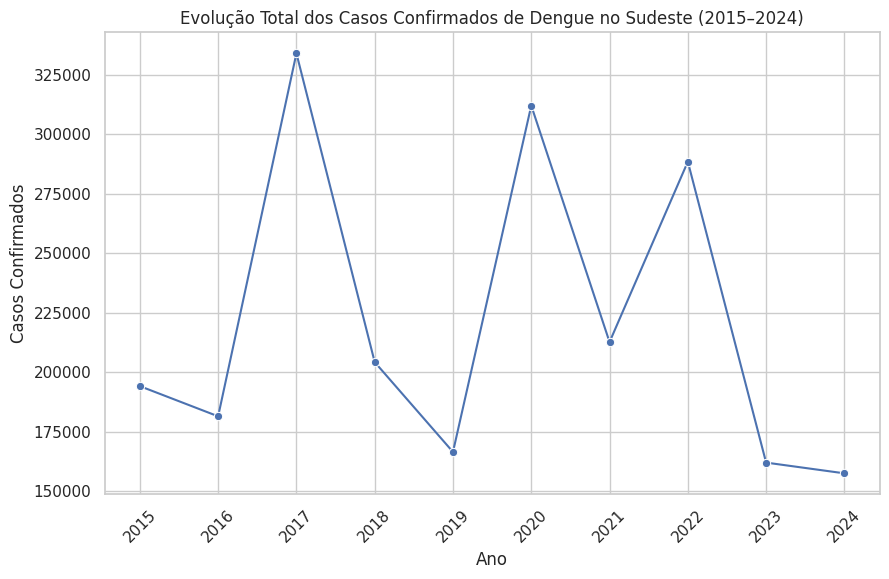

In [9]:

# Gráfico 1: evolução total dos casos no Sudeste ao longo do tempo
plt.figure(figsize=(10, 6))
sns.lineplot(data=casos_por_ano, x="Ano", y="Casos_Confirmados", marker="o")
plt.title("Evolução Total dos Casos Confirmados de Dengue no Sudeste (2015–2024)")
plt.xlabel("Ano")
plt.ylabel("Casos Confirmados")
plt.xticks(casos_por_ano["Ano"], rotation=45)
plt.show()


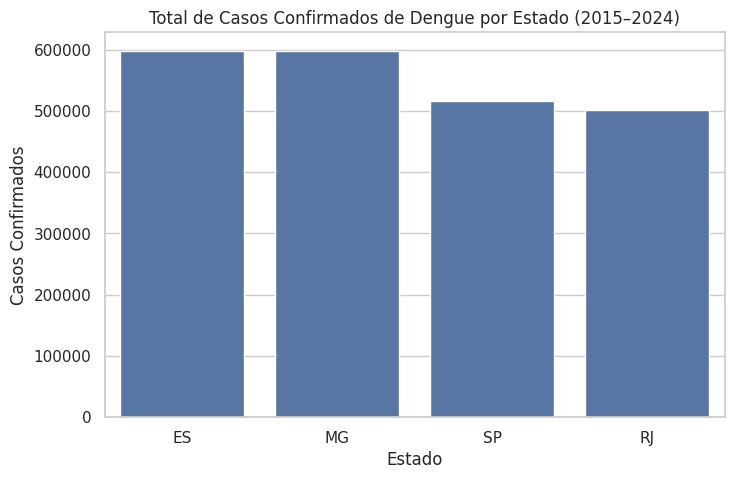

In [10]:

# Gráfico 2: comparação do total de casos por estado no período completo
plt.figure(figsize=(8, 5))
sns.barplot(data=casos_por_estado, x="Estado", y="Casos_Confirmados")
plt.title("Total de Casos Confirmados de Dengue por Estado (2015–2024)")
plt.xlabel("Estado")
plt.ylabel("Casos Confirmados")
plt.show()


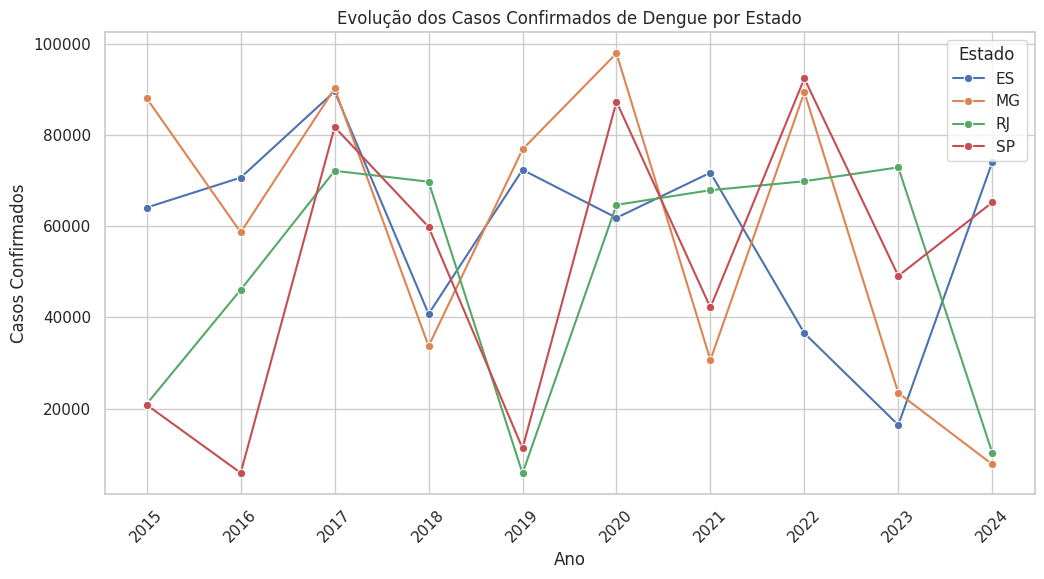

In [11]:

# Gráfico 3: evolução dos casos por estado ao longo do tempo
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Ano", y="Casos_Confirmados", hue="Estado", marker="o")
plt.title("Evolução dos Casos Confirmados de Dengue por Estado")
plt.xlabel("Ano")
plt.ylabel("Casos Confirmados")
plt.xticks(sorted(df["Ano"].unique()), rotation=45)
plt.legend(title="Estado")
plt.show()


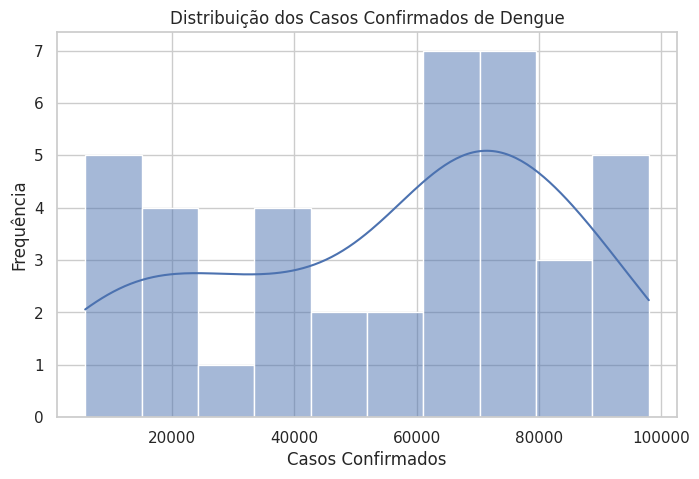

In [12]:

# Gráfico 4: distribuição dos casos confirmados
plt.figure(figsize=(8, 5))
sns.histplot(df["Casos_Confirmados"], bins=10, kde=True)
plt.title("Distribuição dos Casos Confirmados de Dengue")
plt.xlabel("Casos Confirmados")
plt.ylabel("Frequência")
plt.show()



## 8. Insights e interpretação

A seguir, vamos registrar interpretações que vão além da simples descrição dos gráficos.


In [13]:

# Identificação do ano com maior total de casos
ano_critico = casos_por_ano.loc[casos_por_ano["Casos_Confirmados"].idxmax()]
ano_critico


,2
Ano,2017
Casos_Confirmados,334000


In [14]:

# Estado com maior número acumulado de casos no período
estado_mais_afetado = casos_por_estado.loc[casos_por_estado["Casos_Confirmados"].idxmax()]
estado_mais_afetado


,0
Estado,ES
Casos_Confirmados,598463


### Insights e Interpretação dos Resultados

Aqui estão as principais interpretações dos resultados obtidos:

**Insight 1 — Evolução temporal**  
A série histórica mostra que os casos de dengue não se mantêm estáveis ao longo do tempo. Há anos com elevação mais acentuada, indicando períodos críticos que podem estar relacionados à sazonalidade, condições climáticas favoráveis ao mosquito e eficiência variável das ações de prevenção.

**Insight 2 — Comparação entre estados**  
A comparação entre os estados revela que alguns concentram maior volume de casos ao longo do período analisado. Isso pode indicar diferenças de densidade populacional, urbanização, condições sanitárias e capacidade de resposta do sistema de saúde.

**Insight 3 — Ano crítico**  
A identificação do ano com maior número de casos é importante porque permite direcionar análises complementares: o que aconteceu nesse período? Houve surto regional? Condições climáticas favoráveis? Redução de campanhas de combate?

**Insight 4 — Limitações da análise**  
Esta base permite comparar volumes de casos, mas não inclui variáveis climáticas, densidade populacional, cobertura de campanhas ou taxa por habitantes. Portanto, os resultados mostram padrões importantes, mas não explicam sozinhos todas as causas.


## 9. Conclusão

Com base na análise realizada, é possível concluir que os casos confirmados de dengue variam significativamente ao longo do tempo e entre os estados do Sudeste. Alguns anos se destacam como períodos críticos, e determinados estados concentram maior volume de casos.

Esses resultados reforçam a importância de políticas contínuas de prevenção, monitoramento e combate ao mosquito, especialmente em períodos e regiões com maior risco.

**Resposta à pergunta inicial:**  
Os casos de dengue apresentaram oscilações relevantes entre 2015 e 2024, com concentração maior em alguns estados e anos críticos bem definidos, indicando a necessidade de ações regionais mais direcionadas.


## 10. Reflexão Final (Data Storytelling)

**Mensagem Principal para um Gestor Público:**

“Os casos de dengue não se distribuem de forma uniforme ao longo do tempo nem entre os estados. Há períodos e locais mais críticos, o que exige ações preventivas direcionadas, monitoramento contínuo e priorização de recursos.”

### Ações Recomendadas

Com base nesta análise, é crucial intensificar campanhas preventivas nos estados mais afetados e reforçar o monitoramento em anos de maior risco. Para futuras análises, sugere-se a integração dos dados de dengue com variáveis climáticas e demográficas, a fim de obter uma compreensão mais aprofundada dos fatores de risco.